 # Computer Vision

## imports

In [1]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch

from torch import nn

import torchvision


from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

from timeit import default_timer as timer

import tqdm


from tqdm.auto import tqdm

B:\anaconda\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## helpfull stuff

In [3]:
def show_dataset(images, lables):
    fig = plt.figure(figsize=(9, 5))
    rows, cols = 4, 8

    
    for i in range(0, rows*cols):
        img = images[i]
        label = lables[i]
        fig.add_subplot(rows, cols, i+1)
        plt.imshow(img.squeeze(), cmap = "gray")
        plt.title(class_names[label])
        plt.axis(False)

In [4]:
def accuracy(y_real, y_pred):
    
    correct = torch.eq(y_real, y_pred).sum().item()
    acc = (correct/len(y_pred)) * 100

    return acc

In [5]:
def print_train_time(start: float, end: float, device: torch.device = None):
    
    time = end - start
    print(f"Train time on {device} is: {time: .4f}")
    return time

## datasets

In [6]:
train_data = datasets.FashionMNIST(
    root = "data",
    train = True,
    download = True,
    transform = torchvision.transforms.ToTensor(),
    target_transform = None
)

test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = torchvision.transforms.ToTensor(),
    target_transform = None
)


In [7]:
class_names = train_data.classes
class_names


['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Text(0.5, 1.0, 'Ankle boot')

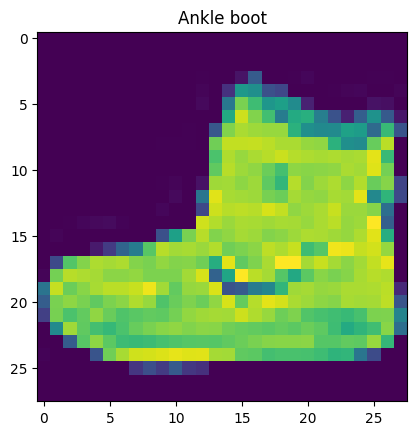

In [8]:
image_sample, image_sample_label = train_data[0]

plt.imshow(image_sample.squeeze())

plt.title(class_names[image_sample_label])

In [9]:
print(class_names)
print(matplotlib.get_backend())

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


NameError: name 'matplotlib' is not defined

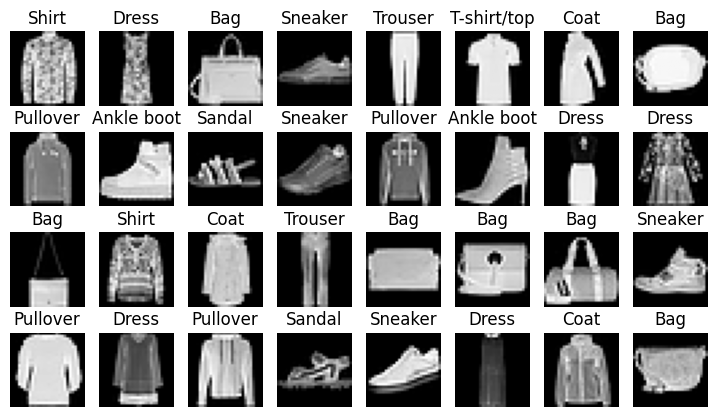

In [10]:
#torch.manual_seed(42)

fig = plt.figure(figsize=(9, 5))
rows, cols = 4, 8

for i in range(1, rows*cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap = "gray")
    plt.title(class_names[label])
    plt.axis(False)


## preparing data

In [11]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(dataset = train_data, batch_size = BATCH_SIZE, shuffle = True)

test_dataloader = DataLoader(dataset = test_data, batch_size = BATCH_SIZE, shuffle = False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x28a8f18e120>,
 <torch.utils.data.dataloader.DataLoader at 0x28a91990b90>)

In [12]:
print(f"Data loader: {train_dataloader, test_dataloader}")
print(f"Lenght of train_dataloader: {len(train_dataloader)} bathes of: {BATCH_SIZE}")
print(f"Lenght of test_dataloader:  {len(test_dataloader)} bathes of: {BATCH_SIZE}")

Data loader: (<torch.utils.data.dataloader.DataLoader object at 0x0000028A8F18E120>, <torch.utils.data.dataloader.DataLoader object at 0x0000028A91990B90>)
Lenght of train_dataloader: 1875 bathes of: 32
Lenght of test_dataloader:  313 bathes of: 32


<>:8: SyntaxWarning: invalid escape sequence '\/'
<>:8: SyntaxWarning: invalid escape sequence '\/'
C:\Users\khan\AppData\Local\Temp\ipykernel_19448\2660229711.py:8: SyntaxWarning: invalid escape sequence '\/'
  print("                                                 \/ \n")


train data batch shape: torch.Size([32, 1, 28, 28]) train labels batch shap: torch.Size([32]) 

                                          -----------------
                                          | Batch preview |
                                          ----------------- 

                                                 ||
                                                 ||
                                                 \/ 



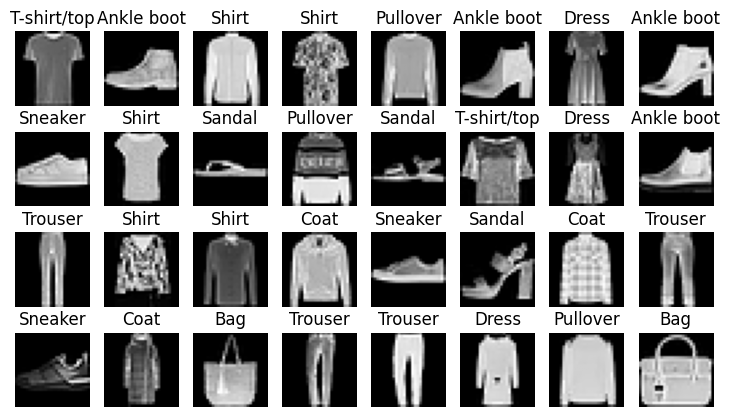

In [13]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
print(f"train data batch shape: {train_features_batch.shape} train labels batch shap: {train_labels_batch.shape} \n")
print("                                          -----------------")
print("                                          | Batch preview |")
print("                                          ----------------- \n")
print("                                                 ||")
print("                                                 ||")
print("                                                 \/ \n")
show_dataset(train_features_batch, train_labels_batch)

## praparing model

In [14]:
class CVM_V0(nn.Module):
    def __init__(self, in_shape: int, out_shape: int, hidden_units: int):
        super().__init__()

        self.model_struct = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = in_shape, out_features = hidden_units),
            nn.Softplus(),
            nn.Linear(in_features = hidden_units, out_features = out_shape),
            nn.Softplus()
        )

    def forward(self, x):
        return self.model_struct(x)

In [15]:
torch.manual_seed(42)

model_0 = CVM_V0(in_shape = 784, out_shape = len(class_names), hidden_units = 10).to("cpu")

model_0

CVM_V0(
  (model_struct): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Softplus(beta=1.0, threshold=20.0)
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): Softplus(beta=1.0, threshold=20.0)
  )
)

### praparing optimizer

In [17]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(), lr = 0.1 )

In [18]:
start_time = timer()

end_time = timer()

print_train_time(start = start_time, end = end_time, device = "cpu")

Train time on cpu is:  0.0000


1.900000006571645e-05

In [19]:

time_start = timer()

epoches = 6


for epoch in tqdm(range(epoches)):
    print(f"Epoch: {epoch}\n------")

    train_loss, train_acc = 0, 0

    for batch, (X, y) in enumerate(train_dataloader):

        
        model_0.train()

        y_pred = model_0(X.to("cpu"))

        loss = loss_fn(y_pred.to("cpu"), y.to("cpu"))

        train_loss += loss
        train_acc += accuracy(y_real = y.to("cpu"), y_pred = y_pred.argmax(dim=1).to("cpu"))
        
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")


    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    
    test_loss, test_acc = 0, 0
    model_0.eval()

    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            
            test_pred = model_0(X_test.to("cpu"))

            test_loss += loss_fn(test_pred.to("cpu"), y_test.to("cpu"))

            test_acc += accuracy(y_real = y_test.to("cpu"), y_pred = test_pred.argmax(dim=1).to("cpu"))

            
        test_loss  /= len(test_dataloader)
        test_acc   /= len(test_dataloader)

    print(f"\nTrain loss: {train_loss: .4f}, Train acc: {train_acc: .4f}  ||  Test loss: {test_loss: .4f}  Test acc: {test_acc: .4f}")

time_end = timer()

print_train_time(start = time_start, end = time_end, device = str(next(model_0.parameters()).device))

  0%|          | 0/6 [00:00<?, ?it/s]

Epoch: 0
------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 17%|█▋        | 1/6 [00:05<00:26,  5.22s/it]


Train loss:  0.6412, Train acc:  77.2483  ||  Test loss:  0.4907  Test acc:  82.8375
Epoch: 1
------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 33%|███▎      | 2/6 [00:10<00:20,  5.19s/it]

...

 83%|████████▎ | 5/6 [00:26<00:05,  5.23s/it]


Train loss:  0.4060, Train acc:  85.2867  ||  Test loss:  0.4400  Test acc:  84.5248
Epoch: 5
------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


100%|██████████| 6/6 [00:31<00:00,  5.24s/it]


Train loss:  0.3977, Train acc:  85.7000  ||  Test loss:  0.4369  Test acc:  85.0140
Train time on cpu is:  31.4567


31.456732399999964

In [20]:
str(next(model_0.parameters()).device)

'cpu'

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

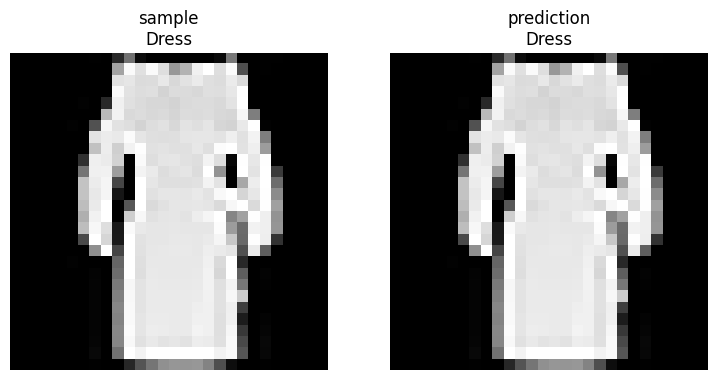

In [21]:
fig = plt.figure(figsize=(9, 5))
rows, cols = 1, 2

random_idx = torch.randint(0, len(test_data), size=[1]).item()

img, label = test_data[random_idx]
fig.add_subplot(rows, cols, 1)
plt.imshow(img.squeeze(), cmap = "gray")
plt.title("sample\n" + class_names[label])
plt.axis(False)

img, label = test_data[random_idx]
fig.add_subplot(rows, cols, 2)
plt.imshow(img.squeeze(), cmap = "gray")
plt.title("prediction\n" + class_names[model_0(img.to("cpu")).argmax(dim=1).item()])
plt.axis(False)